# Setup

## Imports

In [1]:
import math
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go
import seaborn as sns
from IPython.display import Markdown as Md
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    precision_score,
    r2_score,
    recall_score,
    root_mean_squared_error,
    silhouette_score,
)
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler


## Global Vars

### `DATASETS_PATH`

In [2]:
DATASETS_PATH = Path('../datasets/')

### `df_test`

In [3]:
df_test = pd.read_csv(DATASETS_PATH / 'train.csv')

In [4]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [5]:
df_test.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [6]:
df_test.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [7]:
ff.create_distplot(
    hist_data=[
        df_test["SalePrice"],
    ],
    group_labels=[
        "SalePrice",
    ],
    show_hist=False,
    # show_rug=False,
).update_layout(
    margin=dict(t=40, l=40, b=40, r=40),
).show()


### `df_train`

In [8]:
df_train = pd.read_csv(DATASETS_PATH / 'train.csv')

In [9]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [10]:
df_train.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [11]:
df_train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### Distribuição dos valores em `SalePrice`

In [12]:
px.violin(df_train, y='SalePrice', box=True, points='all')


<Axes: xlabel='SalePrice', ylabel='Density'>

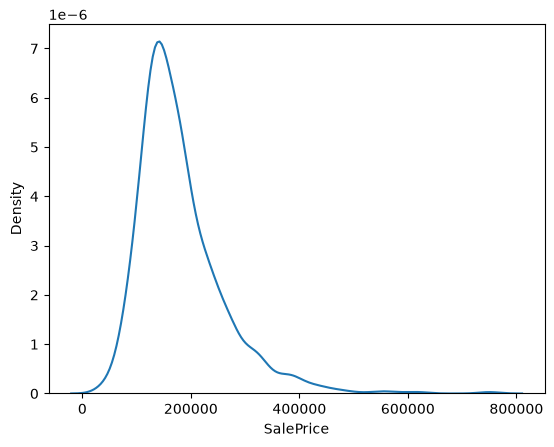

In [13]:
sns.kdeplot(df_train, x='SalePrice')


In [14]:
ff.create_distplot(
    hist_data=[
        df_train["SalePrice"],
    ],
    group_labels=[
        "SalePrice",
    ],
    show_hist=False,
    # show_rug=False,
).update_layout(
    margin=dict(t=40, l=40, b=40, r=40),
).show()


#### Removendo outliers

In [15]:
def get_df_without_outliers_by_irq(
    df: pd.DataFrame,
    col: str,
    # Mild outliers or Extreme outliers
    ol_type: Literal['mild', 'extreme'] = 'mild',
) -> pd.DataFrame:
    if ol_type == 'mild':
        multiplier = 1.5
    elif ol_type == 'extreme':
        multiplier = 3
    else:
        raise ValueError("'ol_type' need's to be 'mild' or 'extreme'")

    QUANTILE = 0.25
    q1 = df[col].quantile(QUANTILE)
    q3 = df[col].quantile(1 - QUANTILE)
    irq = q3 - q1

    return df[
        df[col].between(
            q1 - (multiplier * irq),
            q3 + (multiplier * irq)
        )
    ]


In [16]:
print(
    'Qtd. de linhas Originais =',
    df_train.shape[0]
)
print(
    'Qtd. de linhas removidas (Mild Outliers) =',
    df_train.shape[0] - get_df_without_outliers_by_irq(df_train, col='SalePrice', ol_type='mild').shape[0]
)
print(
    'Qtd. de linhas removidas (Extreme Outliers) =',
    df_train.shape[0] - get_df_without_outliers_by_irq(df_train, col='SalePrice', ol_type='extreme').shape[0]
)


Qtd. de linhas Originais = 1460
Qtd. de linhas removidas (Mild Outliers) = 61
Qtd. de linhas removidas (Extreme Outliers) = 12


In [17]:
# sns.kdeplot(
#     df_train,
#     x='SalePrice',
#     label='With Outliers',
# )

# sns.kdeplot(
#     get_df_without_outliers_by_irq(df_train, col='SalePrice', ol_type='mild'),
#     x='SalePrice',
#     label='Without Mild Outliers',
# )

# sns.kdeplot(
#     get_df_without_outliers_by_irq(df_train, col='SalePrice', ol_type='extreme'),
#     x='SalePrice',
#     label='Without Extreme Outliers',
# )

# plt.legend()
# plt.plot()


In [18]:
fig: go.Figure = ff.create_distplot(
    hist_data=[
        df_train["SalePrice"],

        get_df_without_outliers_by_irq(
            df_train,
            col="SalePrice",
            ol_type="mild",
        )["SalePrice"],

        get_df_without_outliers_by_irq(
            df_train,
            col="SalePrice",
            ol_type="extreme",
        )["SalePrice"],
    ],
    group_labels=[
        "With Outliers",
        "Without Mild Outliers",
        "Without Extreme Outliers",
    ],
    show_hist=False,
    show_rug=False,
)

fig.update_layout(
    margin=dict(t=40, l=40, b=40, r=40),
).show()


# Estudo de Correlação

In [19]:
display(Md('> Colunas:'))
display(df_train.columns)

display(Md('> Colunas numéricas:'))
display(df_train.select_dtypes(include='number').columns)


> Colunas:

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

> Colunas numéricas:

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='str')

## `corr_matrix`

In [20]:
def get_corr_matrix(df_train: pd.DataFrame) -> pd.DataFrame:
    return (
        df_train
        # .drop(columns=['Id', 'MiscVal', 'MiscFeature'])
        .drop(columns=['Id'])
        # .select_dtypes(include='number').corr()
        .corr(numeric_only=True)
    )


get_corr_matrix(df_train)


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
MSSubClass,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,-0.065649,...,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284
LotFrontage,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,0.049900,...,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799
LotArea,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,0.111170,...,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843
OverallQual,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,-0.059119,...,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982
OverallCond,-0.059316,-0.059213,-0.005636,-0.091932,1.000000,-0.375983,0.073741,-0.128101,-0.046231,0.040229,...,-0.003334,-0.032589,0.070356,0.025504,0.054811,-0.001985,0.068777,-0.003511,0.043950,-0.077856
YearBuilt,0.027850,0.123349,0.014228,0.572323,-0.375983,1.000000,0.592855,0.315707,0.249503,-0.049107,...,0.224880,0.188686,-0.387268,0.031355,-0.050364,0.004950,-0.034383,0.012398,-0.013618,0.522897
YearRemodAdd,0.040581,0.088866,0.013788,0.550684,0.073741,0.592855,1.000000,0.179618,0.128451,-0.067759,...,0.205726,0.226298,-0.193919,0.045286,-0.038740,0.005829,-0.010286,0.021490,0.035743,0.507101
MasVnrArea,0.022936,0.193458,0.104160,0.411876,-0.128101,0.315707,0.179618,1.000000,0.264736,-0.072319,...,0.159718,0.125703,-0.110204,0.018796,0.061466,0.011723,-0.029815,-0.005965,-0.008201,0.477493
BsmtFinSF1,-0.069836,0.233633,0.214103,0.239666,-0.046231,0.249503,0.128451,0.264736,1.000000,-0.050117,...,0.204306,0.111761,-0.102303,0.026451,0.062021,0.140491,0.003571,-0.015727,0.014359,0.386420
BsmtFinSF2,-0.065649,0.049900,0.111170,-0.059119,0.040229,-0.049107,-0.067759,-0.072319,-0.050117,1.000000,...,0.067898,0.003093,0.036543,-0.029993,0.088871,0.041709,0.004940,-0.015211,0.031706,-0.011378


## `corr_series`

In [21]:
# with np.printoptions(threshold=np.inf, linewidth=np.inf):
#     # upper triangular matrix
#     print(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))


In [22]:
# def get_corr_table(corr_matrix: pd.DataFrame) -> pd.DataFrame:
#     corr_table = (
#         corr_matrix
#         # Keeps only upper triangle (removes duplicate correlations and diagonal)
#         .where( np.triu(np.ones(corr_matrix.shape), k=1).astype(bool) )
#         # Converts from wide format to long format (stacks columns into rows)
#         .stack()
#         # Drop missing values (duplicate correlations and diagonal)
#         .dropna()
#         # Converts index to regular columns
#         .reset_index()
#         # Renames columns to Portuguese: Variable 1, Variable 2, Correlation
#         .rename(columns={'level_0': 'Variável 1', 'level_1': 'Variável 2', 0: 'Correlação'})
#         # Sorts by correlation strength (highest first)
#         .sort_values(by='Correlação', ascending=False)
#         # Resets index after sorting
#         .reset_index(drop=True)
#     )

#     # Apenas as features com Correlação de Pearson com 'SalePrice' >=0.5
#     corr_table = corr_table[
#         ((corr_table['Variável 1'] == 'SalePrice') | (corr_table['Variável 2'] == 'SalePrice'))
#         & (corr_table['Correlação'] >= 0.5)
#     ].reset_index(drop=True)

#     return corr_table


# get_corr_table(
#     get_corr_matrix(df_train)
# )


In [23]:
def get_corr_series(df: pd.DataFrame, col: str) -> pd.DataFrame:
    return (
        df.corr(numeric_only=True)[col]
        .drop(col)
        .sort_values(key=abs, ascending=False)
    )


corr_series = get_corr_series(
    df_train,
    col='SalePrice',
)
corr_series


OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
KitchenAbvGr    -0.135907
EnclosedPorch   -0.128578
ScreenPorch      0.111447
PoolArea         0.092404
MSSubClass      -0.084284
OverallCond     -0.077856
MoSold           0.046432
3SsnPorch        0.044584
YrSold          -0.028923
LowQualFinSF    -0.025606
Id              -0.021917
MiscVal         -0.021190
BsmtHalfBath    -0.016844
BsmtFinSF2      -0.011378
Name: SalePrice, dtype: float64

<Axes: >

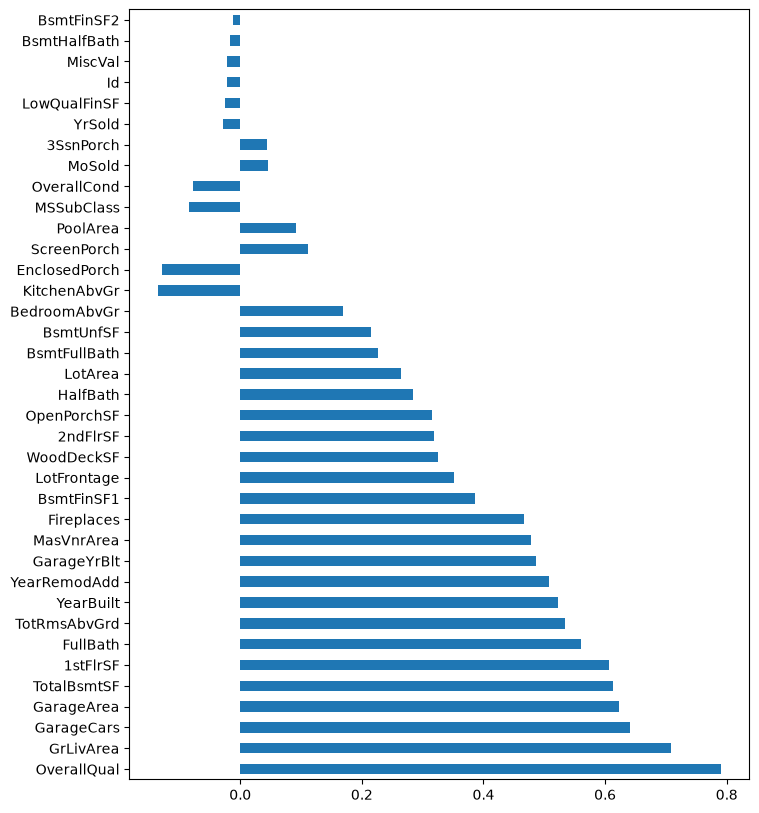

In [24]:
corr_series.plot.barh(figsize=(8, 10))


In [25]:
# df = df_train
# cols = corr_series.index

# fig, axes = plt.subplots(5, 2, figsize=(12, 18))

# for ax, col in zip(axes.flat, cols):
#     ax.scatter(df[col], df["SalePrice"], s=8)
#     ax.set_title(col)

# plt.tight_layout()


## Visualize linear correlations

In [26]:
def plot_linear_corr(df: pd.DataFrame, y_col: str, x_cols):
    n_cols = 3
    n_rows = math.ceil(len(x_cols) / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 4 * n_rows),
        constrained_layout=True,
    )

    axes = axes.ravel()

    for ax, col in zip(axes, x_cols):
        sns.regplot(
            data=df,
            x=col,
            y=y_col,
            scatter_kws={"s": 10, "alpha": 0.5},
            line_kws={"color": "red"},
            ax=ax,
        )
        ax.set_title(col)

    for ax in axes[len(x_cols):]:
        fig.delaxes(ax)

    plt.show()


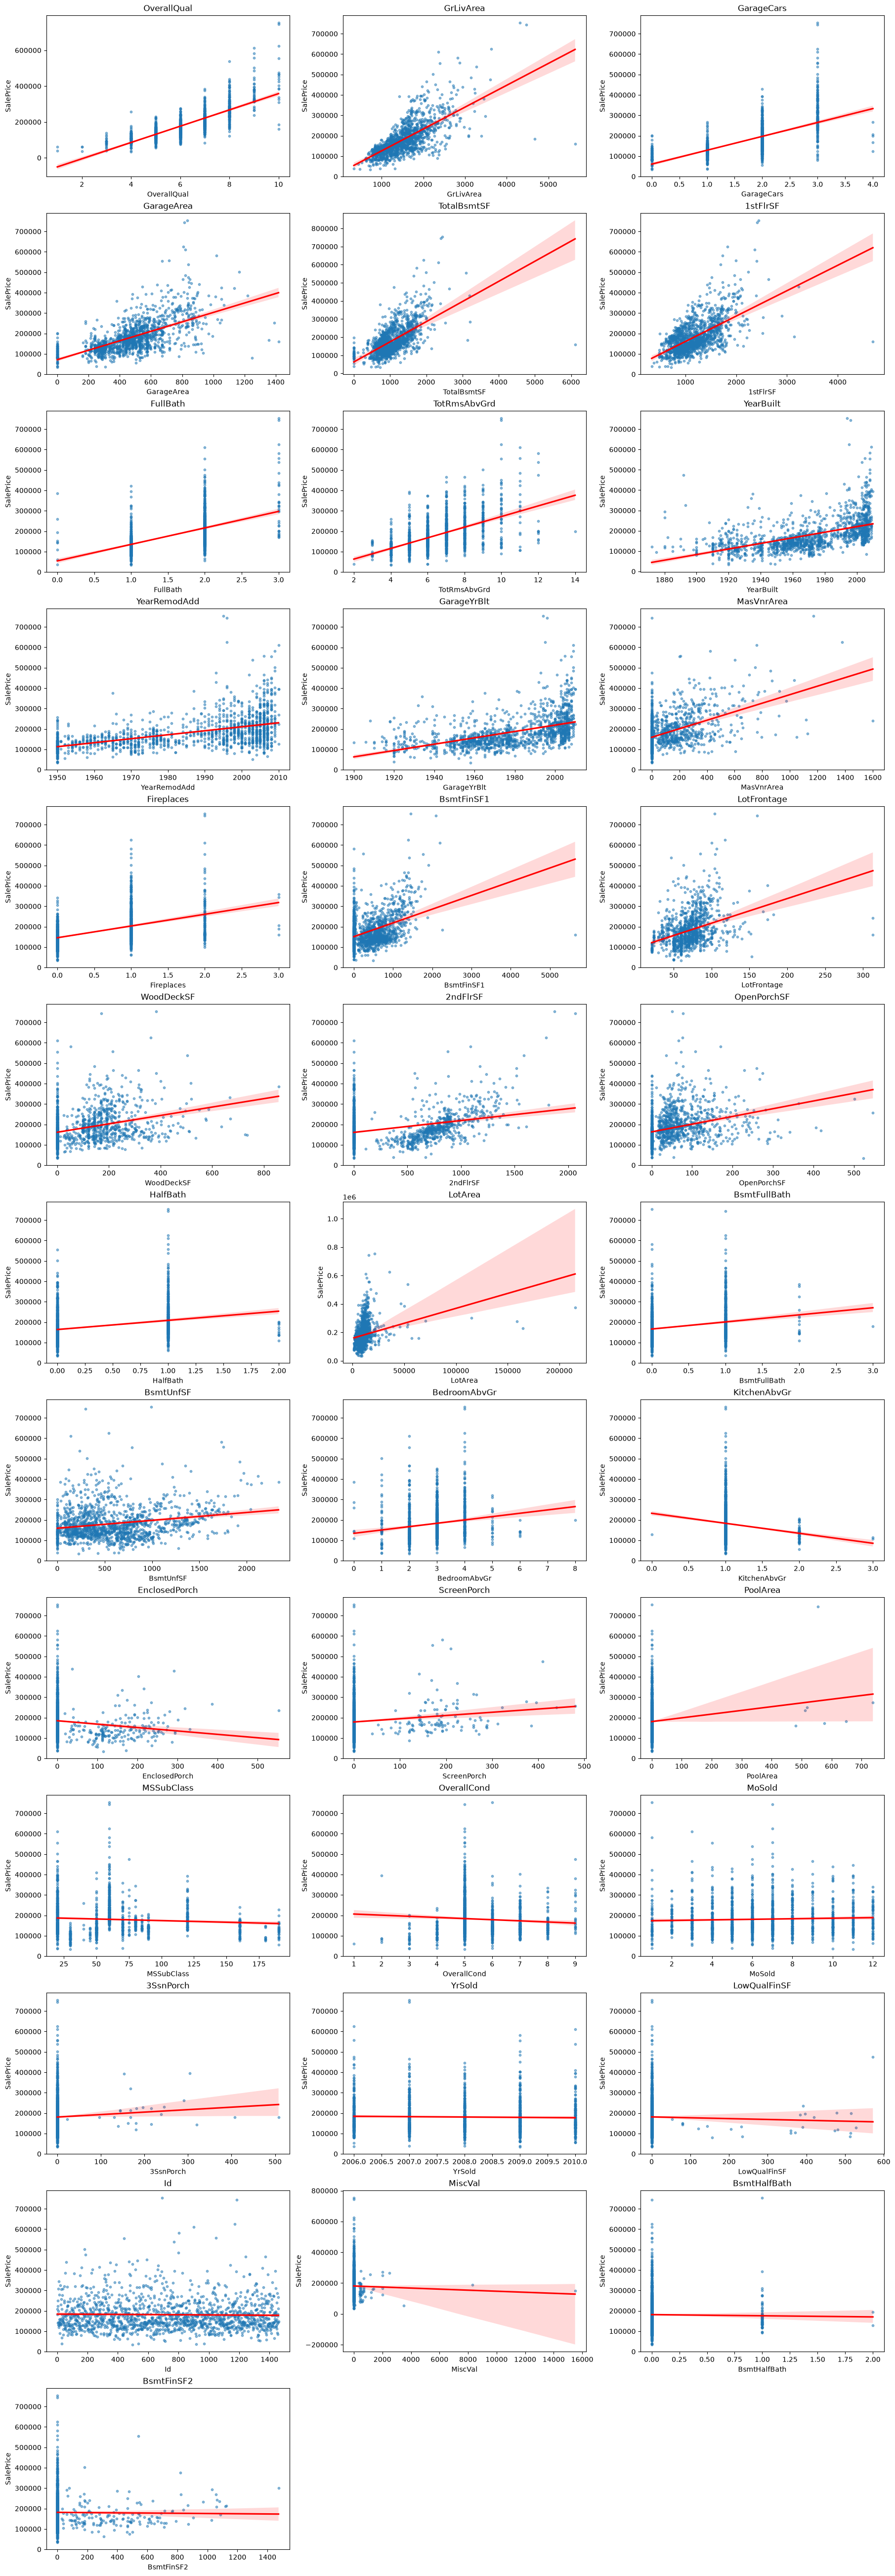

In [27]:
plot_linear_corr(
    df_train,
    y_col='SalePrice',
    x_cols=corr_series.index,
)


# Aprendizagem Supervisionada

## Regressão Linear

In [28]:
def _linear_regression(
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    x_cols: list[str],
    y_col: str,
):
    X_train = df_train[x_cols]
    y_train = df_train[y_col]

    X_test = df_test[x_cols]
    y_test = df_test[y_col]

    # Train
    modelo = LinearRegression()
    modelo.fit(X_train, y_train)

    # Pred
    y_pred = modelo.predict(X_test)


    # Métricas
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Residual Standard Error (RSE)
    n = len(y_test)
    p = X_test.shape[1]  # número de variáveis explicativas

    rss = np.sum((y_test - y_pred) ** 2)
    rse = np.sqrt(rss / (n - p - 1))


    print(f"RMSE: {rmse:.2f}")
    print(f"RSE : {rse:.2f}")
    print(f"MAE : {mae:.2f}")
    print(f"R²  : {r2:.4f}")


_linear_regression(
    df_train,
    df_test=df_test,
    x_cols=['OverallQual'],
    # x_cols=['OverallQual', 'GrLivArea', 'GarageCars'],
    y_col='SalePrice',
)


RMSE: 48589.45
RSE : 48622.76
MAE : 33722.05
R²  : 0.6257


In [29]:
def _logistic_regression(
    df_train: pd.DataFrame,
    df_test: pd.DataFrame,
    x_cols: list[str],
):
    df_train = df_train.copy()
    df_test = df_test.copy()

    limiar = df_train["SalePrice"].median()

    df_train["HighPrice"] = (df_train["SalePrice"] > limiar).astype(int)
    df_test["HighPrice"] = (df_test["SalePrice"] > limiar).astype(int)

    X_train = df_train[x_cols]
    y_train = df_train["HighPrice"]

    X_test = df_test[x_cols]
    y_test = df_test["HighPrice"]

    modelo = LogisticRegression(max_iter=1000)
    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    # y_prob = modelo.predict_proba(X_test)[:, 1]

    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1-score :", f1_score(y_test, y_pred))

    print()
    print(confusion_matrix(y_test, y_pred))
    print()
    print(classification_report(y_test, y_pred))


_logistic_regression(
    df_train,
    df_test=df_test,
    x_cols=['OverallQual'],
    # x_cols=['OverallQual', 'GrLivArea', 'GarageCars'],
)


Accuracy : 0.8136986301369863
Precision: 0.916058394160584
Recall   : 0.6895604395604396
F1-score : 0.786833855799373

[[686  46]
 [226 502]]

              precision    recall  f1-score   support

           0       0.75      0.94      0.83       732
           1       0.92      0.69      0.79       728

    accuracy                           0.81      1460
   macro avg       0.83      0.81      0.81      1460
weighted avg       0.83      0.81      0.81      1460



# Aprendizagem não supervisionada

## Clustering

In [30]:
# X = df_train.select_dtypes(include='number').drop(columns=['SalePrice'])


def _clustering_k_means(
    df: pd.DataFrame,
    x_cols: list[str],
):
    df = df.copy()
    X = df[x_cols]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)


    # # Número de clusters (escolha de K pelo cotovelo)
    # inertia = []

    # for k in range(1, 11):
    #     modelo = KMeans(n_clusters=k, random_state=42)
    #     modelo.fit(X_scaled)
    #     inertia.append(modelo.inertia_)

    # plt.plot(range(1, 11), inertia, marker='o')
    # plt.xlabel('Número de clusters')
    # plt.ylabel('Inertia')
    # plt.show()


    k=3

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init="auto",
    )

    clusters = modelo.fit_predict(X_scaled)


    # df["Cluster"] = clusters
    # # print(df[["Cluster"]].head())
    # print(df.groupby("Cluster")[x_cols + ["SalePrice"]].mean())
    # print(df.groupby("Cluster").mean(numeric_only=True))
    print("Silhouette score:", silhouette_score(X_scaled, clusters))


_clustering_k_means(
    df_train,
    x_cols=[
        'OverallQual',
        'GrLivArea',
        'GarageCars',
        'TotalBsmtSF',
        'YearBuilt',
    ],
)


Silhouette score: 0.2685037588695838


## Redução de dimensionalidade

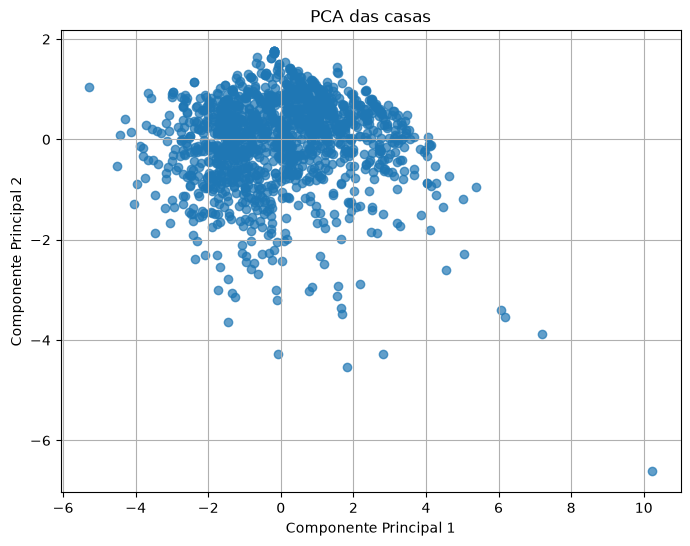

explained_variance_ratio_: [0.58710232 0.16383218]
explained_variance_ratio_.sum():  0.7509344918629235


In [31]:

def _dimensionality_reduction(
    df: pd.DataFrame,
    cols: list[str],
):
    X = df[cols]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_scaled)


    # print(X_pca.shape)

    plt.figure(figsize=(8,6))
    plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        alpha=0.7
    )
    plt.xlabel("Componente Principal 1")
    plt.ylabel("Componente Principal 2")
    plt.title("PCA das casas")
    plt.grid(True)
    plt.show()

    print('explained_variance_ratio_:', pca.explained_variance_ratio_)
    print('explained_variance_ratio_.sum(): ', pca.explained_variance_ratio_.sum())


    # plt.figure(figsize=(8,6))

    # plt.scatter(
    #     X_pca[:,0],
    #     X_pca[:,1],
    #     c=df["Cluster"],
    #     cmap="viridis"
    # )

    # plt.xlabel("PC1")
    # plt.ylabel("PC2")
    # plt.title("PCA com clusters")

    # plt.colorbar(label="Cluster")

    # plt.show()

    # plt.figure(figsize=(8,6))
    # plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.7)
    # plt.xlabel("PC1")
    # plt.ylabel("PC2")
    # plt.title("Visualização dos dados com PCA")
    # plt.grid(True)
    # plt.show()


_dimensionality_reduction(
    df_train,
    cols=[
        'OverallQual',
        'GrLivArea',
        'GarageCars',
        'TotalBsmtSF',
        'YearBuilt',
    ],
)


## Análise de associação

In [32]:
def _association_analysis(
    df_train: pd.DataFrame,
    q_bins: int = 4,
    min_confidence: float = 0.7,
    include_saleprice: bool = True,
):
    # min_support: float = 0.05
    min_lift: float = 1.2

    df = df_train.copy()

    selected_cols = [
        "MSSubClass",
        "BldgType",
        "HouseStyle",
        "OverallQual",
        "OverallCond",
        "Neighborhood",
        "MSZoning",
        "Condition1",
        "LotConfig",
        "LandContour",
        "LandSlope",
        "RoofStyle",
        "Foundation",
        "ExterQual",
        "ExterCond",
        "BsmtQual",
        "BsmtExposure",
        "BsmtFinType1",
        "HeatingQC",
        "CentralAir",
        "KitchenQual",
        "Functional",
        "GarageType",
        "GarageFinish",
        "GarageCars",
        "GarageQual",
        "Fireplaces",
        "FireplaceQu",
        "PavedDrive",
        "Fence",
        "SaleType",
        "SaleCondition",
    ]

    if include_saleprice:
        selected_cols.append("SalePrice")

    df = df[selected_cols]

    # Discretizing
    numeric_cols = df.select_dtypes(include="number").columns

    for col in numeric_cols:
        df[col] = pd.qcut(df[col], q=q_bins, duplicates="drop")

    # Stringify and Fill NA
    df = df.fillna("Missing").astype(str)

    # Transactions
    transactions = df.apply(
        lambda r: [f"{c}={v}" for c, v in r.items()],
        axis=1
    ).tolist()

    # Encoding
    te = TransactionEncoder()
    X = te.fit(transactions).transform(transactions)

    df_encoded = pd.DataFrame(X, columns=te.columns_)

    # temsets frequentes
    itemsets = apriori(
        df_encoded,
        # min_support=min_support,
        use_colnames=True
    )

    # rules
    rules = association_rules(
        itemsets,
        metric="lift",
        min_threshold=min_lift,
    )

    rules = rules[
        (rules["confidence"] >= min_confidence)
    ]

    return rules.sort_values(["lift", "confidence"], ascending=False)


_association_analysis(
    df_train
)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
322,"frozenset({SaleType=WD, BldgType=1Fam, GarageQ...","frozenset({CentralAir=Y, MSZoning=RL, SaleCond...",0.614384,0.626027,0.505479,0.822742,1.314228,1.0,0.120859,2.109770,0.620038,0.687791,0.526015,0.815091
347,"frozenset({CentralAir=Y, MSZoning=RL, SaleCond...","frozenset({SaleType=WD, BldgType=1Fam, GarageQ...",0.626027,0.614384,0.505479,0.807440,1.314228,1.0,0.120859,2.002576,0.639343,0.687791,0.500643,0.815091
315,"frozenset({BldgType=1Fam, SaleCondition=Normal...","frozenset({SaleType=WD, MSZoning=RL, GarageQua...",0.609589,0.632192,0.505479,0.829213,1.311649,1.0,0.120102,2.153614,0.608591,0.686512,0.535664,0.814390
354,"frozenset({SaleType=WD, MSZoning=RL, GarageQua...","frozenset({BldgType=1Fam, SaleCondition=Normal...",0.632192,0.609589,0.505479,0.799567,1.311649,1.0,0.120102,1.947834,0.645991,0.686512,0.486609,0.814390
316,"frozenset({BldgType=1Fam, SaleCondition=Normal...","frozenset({MSZoning=RL, CentralAir=Y, SaleType...",0.585616,0.658219,0.505479,0.863158,1.311353,1.0,0.120015,2.497629,0.572969,0.684601,0.599620,0.815554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1730,"frozenset({LandContour=Lvl, CentralAir=Y, Sale...","frozenset({LandSlope=Gtl, Functional=Typ, Sale...",0.691096,0.630137,0.522603,0.756194,1.200047,1.0,0.087118,1.517040,0.539648,0.654374,0.340821,0.792771
502,"frozenset({LandContour=Lvl, CentralAir=Y, Sale...","frozenset({SaleType=WD, GarageQual=TA, ExterCo...",0.660274,0.679452,0.538356,0.815353,1.200015,1.0,0.089732,1.736001,0.490622,0.671795,0.423964,0.803846
523,"frozenset({SaleType=WD, GarageQual=TA, ExterCo...","frozenset({LandContour=Lvl, CentralAir=Y, Sale...",0.679452,0.660274,0.538356,0.792339,1.200015,1.0,0.089732,1.635962,0.519976,0.671795,0.388739,0.803846
1923,"frozenset({CentralAir=Y, SaleCondition=Normal,...","frozenset({LandSlope=Gtl, Functional=Typ, Sale...",0.641781,0.697260,0.536986,0.836713,1.200001,1.0,0.089498,1.854033,0.465266,0.669513,0.460635,0.803425


In [33]:
def _lof_outlier_detection(
    df_train: pd.DataFrame,
    n_neighbors: int = 20,
    use_pca: bool = True,
) -> pd.DataFrame:
    contamination = 0.05
    pca_variance = 0.95

    df = df_train.drop(columns=["Id", "SalePrice"], errors="ignore")

    # one-hot encoding
    df = pd.get_dummies(df, drop_first=True)

    # missing values
    df = df.fillna(df.median(numeric_only=True))

    # scaling
    X = StandardScaler().fit_transform(df)

    # optional PCA (recomendado para House Prices)
    if use_pca:
        X = PCA(n_components=pca_variance).fit_transform(X)

    # LOF
    lof = LocalOutlierFactor(
        n_neighbors=n_neighbors,
        contamination=contamination
    )

    labels = lof.fit_predict(X)
    scores = lof.negative_outlier_factor_

    result = df_train.copy()
    result["is_outlier"] = labels == -1
    result["lof_score"] = scores

    return result.sort_values("lof_score")


_df_lof = _lof_outlier_detection(
    df_train,
    use_pca=False,
)
print('Qtd. de linhas originalmente:', _df_lof.shape[0])
print('Qtd. de outliers:', _df_lof[_df_lof['is_outlier']].shape[0])


Qtd. de linhas originalmente: 1460
Qtd. de outliers: 73


# Otimizações

In [34]:
display(Md('> Apenas colunas numéricas e sem incluir `Id`'))

_df_numeric = df_train.select_dtypes(include='number')
_df_numeric = _df_numeric[[
    c
    for c in _df_numeric.columns
    if c not in ['Id']
]]

_df_numeric_test = df_test.select_dtypes(include='number')
_df_numeric_test = _df_numeric_test[[
    c
    for c in _df_numeric_test.columns
    if c not in ['Id']
]]

> Apenas colunas numéricas e sem incluir `Id`

In [35]:
display(_df_numeric.shape)
_df_numeric.columns

(1460, 37)

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice'],
      dtype='str')

In [36]:
display(Md('> Substituir valores NaN pela mediana'))

_df_numeric = _df_numeric.fillna(_df_numeric.median(numeric_only=True))
_df_numeric_test = _df_numeric_test.fillna(_df_numeric_test.median(numeric_only=True))


> Substituir valores NaN pela mediana

<Axes: >

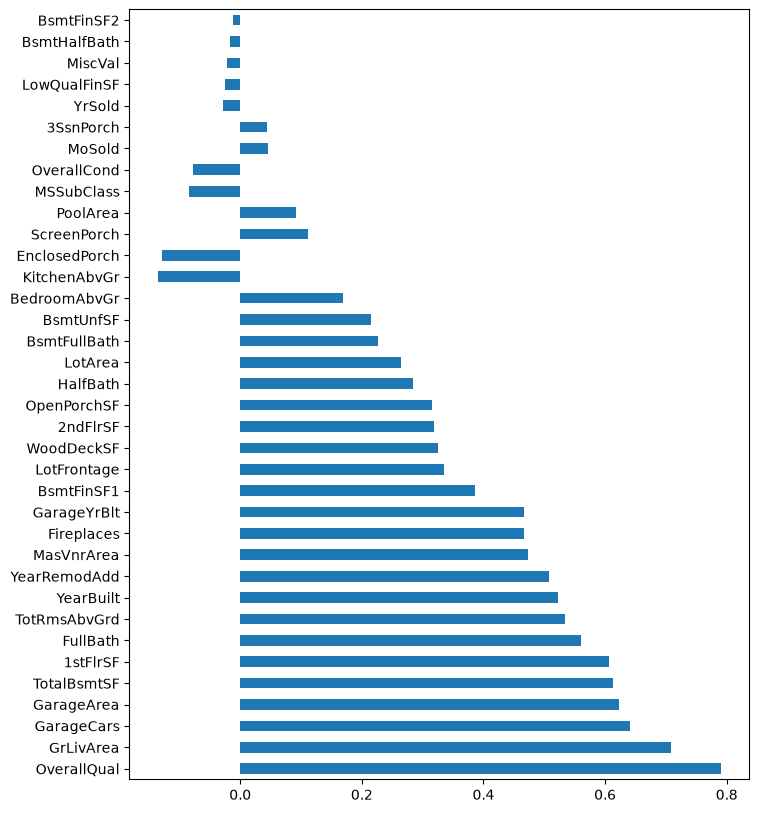

In [37]:
_corr_series = get_corr_series(
    _df_numeric,
    col='SalePrice',
)

_corr_series.plot.barh(figsize=(8, 10))


In [38]:
# df_train.shape, df_train.select_dtypes(include="number").shape
_corr_series.shape

(36,)

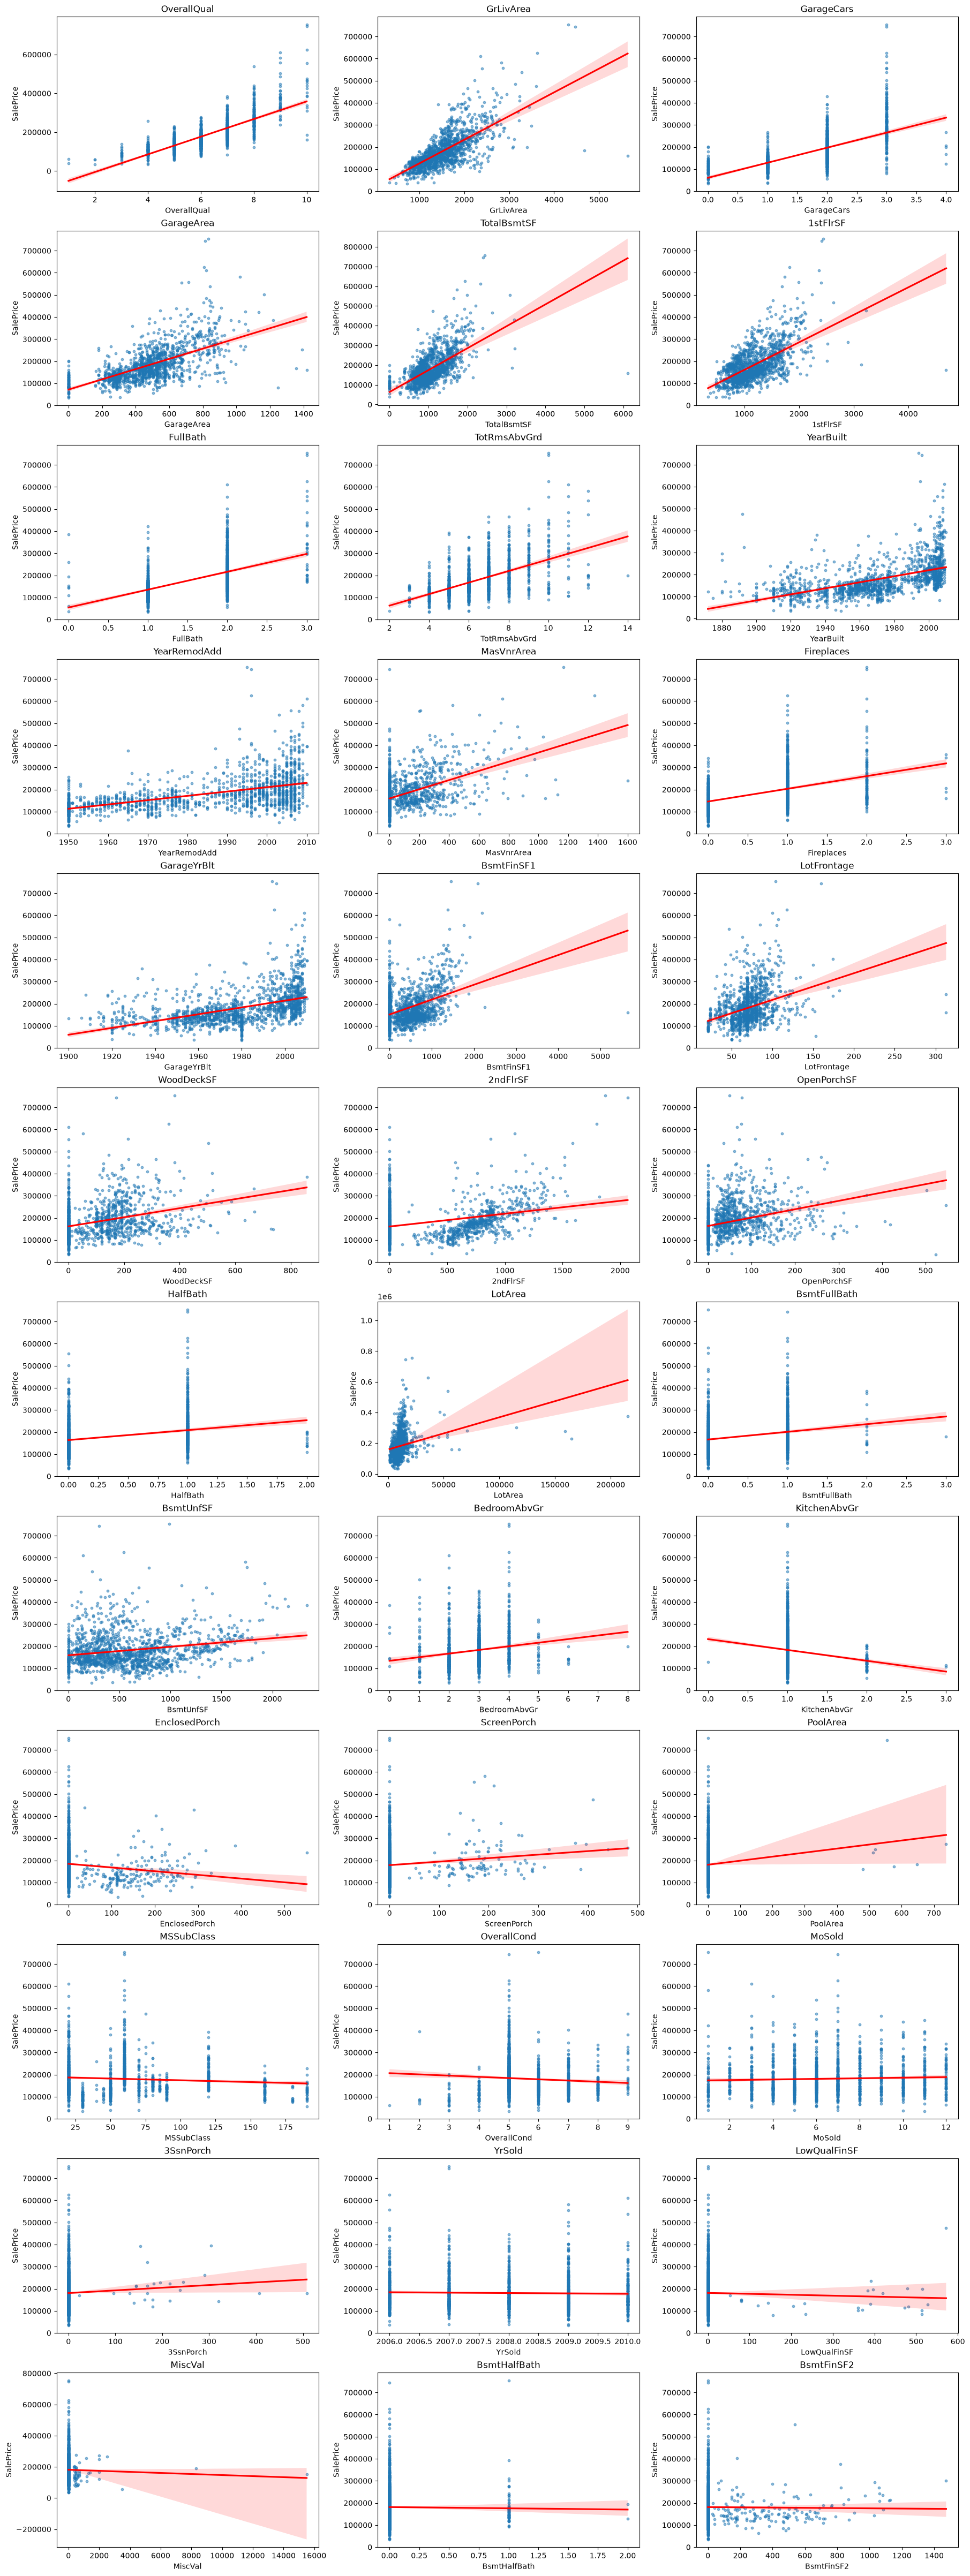

In [39]:
plot_linear_corr(
    _df_numeric,
    y_col='SalePrice',
    x_cols=_corr_series.index,
)


In [40]:
_linear_regression(
    _df_numeric,
    df_test=_df_numeric_test,
    x_cols=['OverallQual'],
    y_col='SalePrice',
)


RMSE: 48589.45
RSE : 48622.76
MAE : 33722.05
R²  : 0.6257


In [41]:
_linear_regression(
    _df_numeric,
    df_test=_df_numeric_test,
    x_cols=['YearRemodAdd'],
    # x_cols=['OverallQual', 'GrLivArea', 'GarageCars'],
    y_col='SalePrice',
)

print()
_linear_regression(
    _df_numeric,
    df_test=_df_numeric_test,
    x_cols=['OverallQual', 'GrLivArea', 'GarageCars', 'YearRemodAdd'],
    y_col='SalePrice',
)

print()
_linear_regression(
    _df_numeric,
    df_test=_df_numeric_test,
    x_cols=_corr_series.index.difference(['Id']).to_list(),
    y_col='SalePrice',
)


RMSE: 68446.98
RSE : 68493.91
MAE : 47201.14
R²  : 0.2572

RMSE: 40054.91
RSE : 40123.67
MAE : 26945.51
R²  : 0.7456

RMSE: 34327.77
RSE : 34771.19
MAE : 21101.00
R²  : 0.8132
